Hello, and welcome to my week 3 assignment. Last week, we worked with a baseball dataset and created some charts to visualize pitch differences. To break the monotony of always doing projects with sports (a habit I fall into too often), we'll be using a different dataset from Kaggle, which we'll just import as a CSV file:

**Environment Setup**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
water = pd.read_csv("waterPollution.csv")

water.describe()

,phenomenonTimeReferenceYear,resultMeanValue,PopulationDensity,TerraMarineProtected_2016_2018,TouristMean_1990_2020,VenueCount,netMigration_2011_2018,droughts_floods_temperature,literacyRate_2010_2018,combustibleRenewables_2009_2014,...,composition_food_organic_waste_percent,composition_glass_percent,composition_metal_percent,composition_other_percent,composition_paper_cardboard_percent,composition_plastic_percent,composition_rubber_leather_percent,composition_wood_percent,composition_yard_garden_green_waste_percent,waste_treatment_recycling_percent
count,20000.000000,20000.000000,19893.000000,19893.000000,1.989300e+04,20000.000000,19893.000000,19893.000000,19893.000000,19893.000000,...,19893.000000,19893.000000,19893.000000,19893.000000,19893.000000,19893.000000,19893.000000,19893.000000,19893.000000,19893.000000
mean,2008.998700,34.444639,149.895102,26.227472,4.919348e+07,0.141400,114206.842878,0.130027,14.859312,4.652609,...,32.166075,7.663619,3.196126,23.519892,18.903705,11.206789,0.159449,2.073875,1.302482,23.312787
std,1.917859,174.643233,75.994558,6.790095,2.469506e+07,1.922314,144682.517527,0.260679,31.565912,3.444092,...,11.326430,3.279468,1.130070,6.551350,4.252571,4.901386,0.731725,3.013117,3.656386,5.958540
min,1991.000000,0.000015,14.548292,3.875411,5.300380e+05,0.000000,-83749.750000,0.000000,0.000000,1.064468,...,12.780000,2.200000,1.380000,0.000000,5.000000,1.450000,0.000000,0.000000,0.000000,0.760000
25%,2008.000000,0.114100,122.299437,23.733280,2.586796e+07,0.000000,21256.750000,0.005718,0.000000,4.363288,...,30.000000,5.440000,3.000000,17.700000,18.900000,9.000000,0.000000,0.000000,0.000000,22.260000
50%,2009.000000,2.000000,122.299437,30.831906,5.094169e+07,0.000000,75808.375000,0.005718,0.000000,4.457840,...,32.000000,10.000000,3.000000,26.000000,20.000000,9.000000,0.000000,0.000000,0.000000,22.260000
75%,2009.000000,10.975625,137.976566,30.831906,7.117635e+07,0.000000,75808.375000,0.032407,0.000000,4.457840,...,32.000000,10.000000,3.000000,26.000000,20.000000,12.400000,0.000000,2.000000,2.700000,27.250000
max,2017.000000,14108.000000,511.475928,38.767234,7.117635e+07,100.000000,582211.000000,0.729194,87.158924,25.982190,...,62.300000,21.400000,9.200000,44.050000,37.830000,22.900000,6.000000,17.210000,30.460000,47.830000


**Chart #1: Comparing Plastic and Metal Content Using Histograms**

This is a pretty large dataset from the European Environment Agency that describes water quality with over 20,000 entries and 21 different columns. There are plenty of interesting variable pairings we can do as it pertains to the quality of water, so let's start with a histogram with two panels to view the distribution of plastic and metal content in our water:

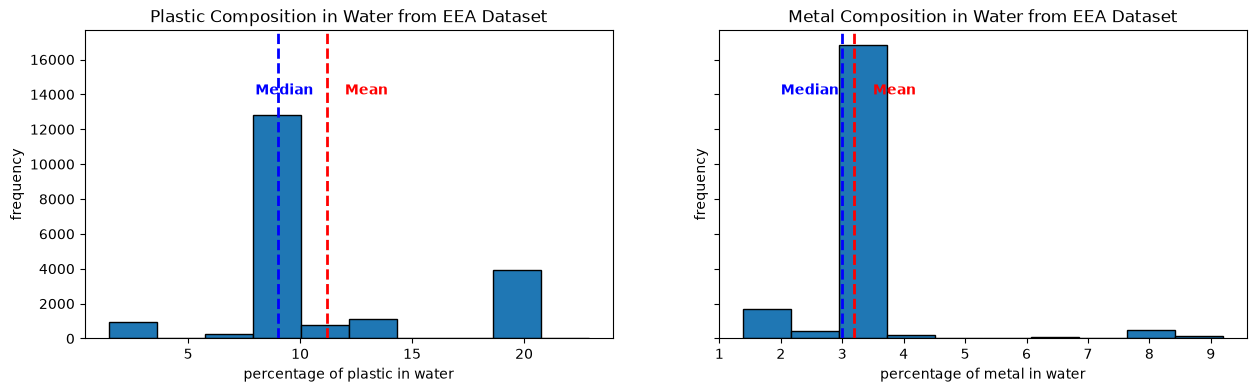

In [33]:
plastic = water['composition_plastic_percent'].values
metal = water['composition_metal_percent'].values

fig, axes = plt.subplots(1, 2, figsize=(15,4), sharey=True)

axes[0].hist(x = plastic, bins = 10, edgecolor = 'black')
axes[0].set_title('Plastic Composition in Water from EEA Dataset')
axes[0].set_xlabel('percentage of plastic in water')
axes[0].set_ylabel('frequency')
axes[0].axvline(x = 11.206789, color='red', linestyle='--', linewidth=2, label=('Mean'))
axes[0].axvline(x = 9, color='blue', linestyle='--', linewidth=2, label=('Median'))
axes[0].text(12, 14000, "Mean", color = 'red', fontweight = 'bold')
axes[0].text(8, 14000, "Median", color = 'blue', fontweight = 'bold')


axes[1].hist(x = metal, bins = 10, edgecolor = 'black')
axes[1].set_title('Metal Composition in Water from EEA Dataset')
axes[1].set_xlabel('percentage of metal in water')
axes[1].set_ylabel('frequency')
axes[1].axvline(x = 3.196126, color='red', linestyle='--', linewidth=2, label=('Mean'))
axes[1].axvline(x = 3, color='blue', linestyle='--', linewidth=2, label=('Median'))
axes[1].text(3.5, 14000, "Mean", color = 'red', fontweight = 'bold')
axes[1].text(2, 14000, "Median", color = 'blue', fontweight = 'bold')

plt.show()

Here, we can observe the difference between plastic and metal composition in water samples from our dataset. I also added a mean line (dotted red) and a median line (dotted blue) to help interpret the centering and spread of out data (values were pulled from water.describe()). We'll also use a small annotation on the chart to demonstrate which line is which. Let's start first with our plastic:

Our distribution of plastic composition in water appears to be roughly unimodal symmetric, with a slight right skew. This appears to be due to a highly frequent occurence of water having around a 20% plastic content, which nearly accounts for 50% of our data (around 4000 occurences in a 20,000 row dataset). Due to the general spread of our dataset, there doesn't really appear to be any outliers, but it's difficult to say that the dataset is really grouped around its mean value of 11%, only that it's the center of the distribution.

Our distribution of metal composition in water is more interesting. While it retains the same rough unimodal symmetric shape centered around our mean value of approximately 3% content, we observe what appeaars to be some significant outlier values around 8-9% content. Surely enough, using the 1.5 IQR rule (numbers from water.describe()), 8-9% falls outside of our positive sided threshold. It's likely that a relationship exists between the high plastic percentage occurences and the high metal percentage occurences. Otherwise, we don't observe any major skew, and our distribution of metal content is far less variable/spread-out than our plastic distribution.

Overall, histograms are probably the best way to view the overall distribution of a variable as it pertains to a specific range of values, but aren't particularly powerful in quantifying the spread of the dataset (standard deviation, quartiles, IQR, and outlier thresholds, for example)

Next, let's produce a joint boxplot-KDE chart to better understand the distribution of our plastic content.

**Chart 2: Representing Distribution Spread Using Boxplots and Violin Plots**

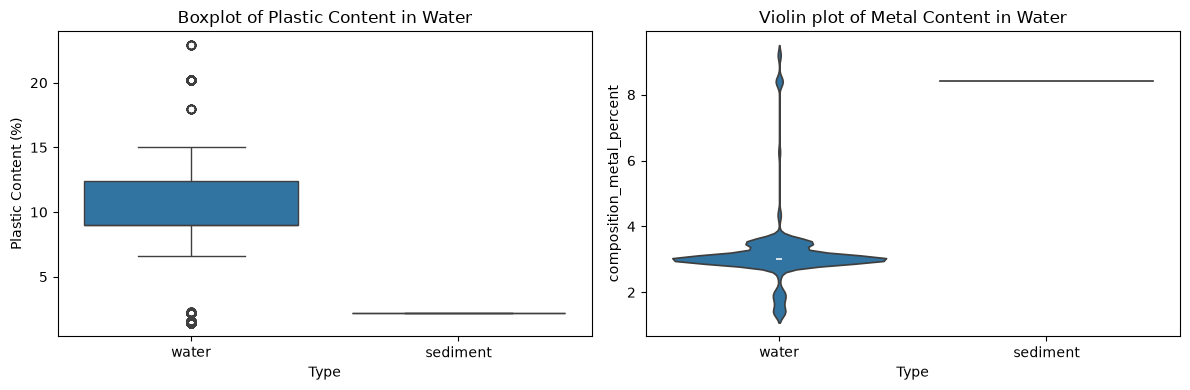

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=False)

sns.boxplot(data=water, x = 'procedureAnalysedMedia', y ='composition_plastic_percent', ax=axes[0])
axes[0].set_title("Boxplot of Plastic Content in Water")
axes[0].set_xlabel("Type")
axes[0].set_ylabel("Plastic Content (%)")

sns.violinplot(data=water, x='procedureAnalysedMedia', y = 'composition_metal_percent', inner='box', ax=axes[1])
axes[1].set_title("Violin plot of Metal Content in Water")
axes[1].set_xlabel("Type")

plt.tight_layout()
plt.show() 



*Note: second category (sediment) is irrelevant, simply was chosen so that plots could display distributions across the entire dataset.*

Unfortunately, due to the distribution of our data, we're forced to create two separate plots for our two different categories of interest so that we can have reasonable plots to analyze. Starting with plastic:

We can more clearly see the relative symmetry of our dataset in boxplot format, and we can also observe outlier values that we didn't previously pick up on when viewing the histogram. We can see that our general spread is relatively minimal, especially when our more extreme values are classified as outliers.

Opposite to a histogram, a boxplot is probably our strongest tool to visualize the spread and outliers of a dataset. However, it tells us little about the actual distribution of the data (tells us nothing of the mean or mode) and it can generally be more difficult to perceive the frequency of a level of observation.

Now, observing our violin plot, we can see that our data is heavily clumped around that 3-4% range of metal composition. It's also easier to observe our heavy right skew as well as notice the extreme outliers of water samples with very high metal concentrations. The centering and spread of the data is also highlighted by the width of our plot.

Overall, I would argue that violin plots are essentially a more effective and detailed version of a boxplot. It similarly succeeds at describing the spread of a distribution (less detail as there are no quartiles, but still shows shape) and still offers the advantage of automatically identifying outliers. However, by varying the width of the figure based on the frequency of the observation, the violin plot is still able to describe the center and shape of the distribution.

Finally, we will observe the difference in the distribution of plastic content across the 5 years with the most observations in our data set (2006-2010) via a facet plot:

**Chart 3: Observing Distribution Differences Across Years Using Facet Plots**

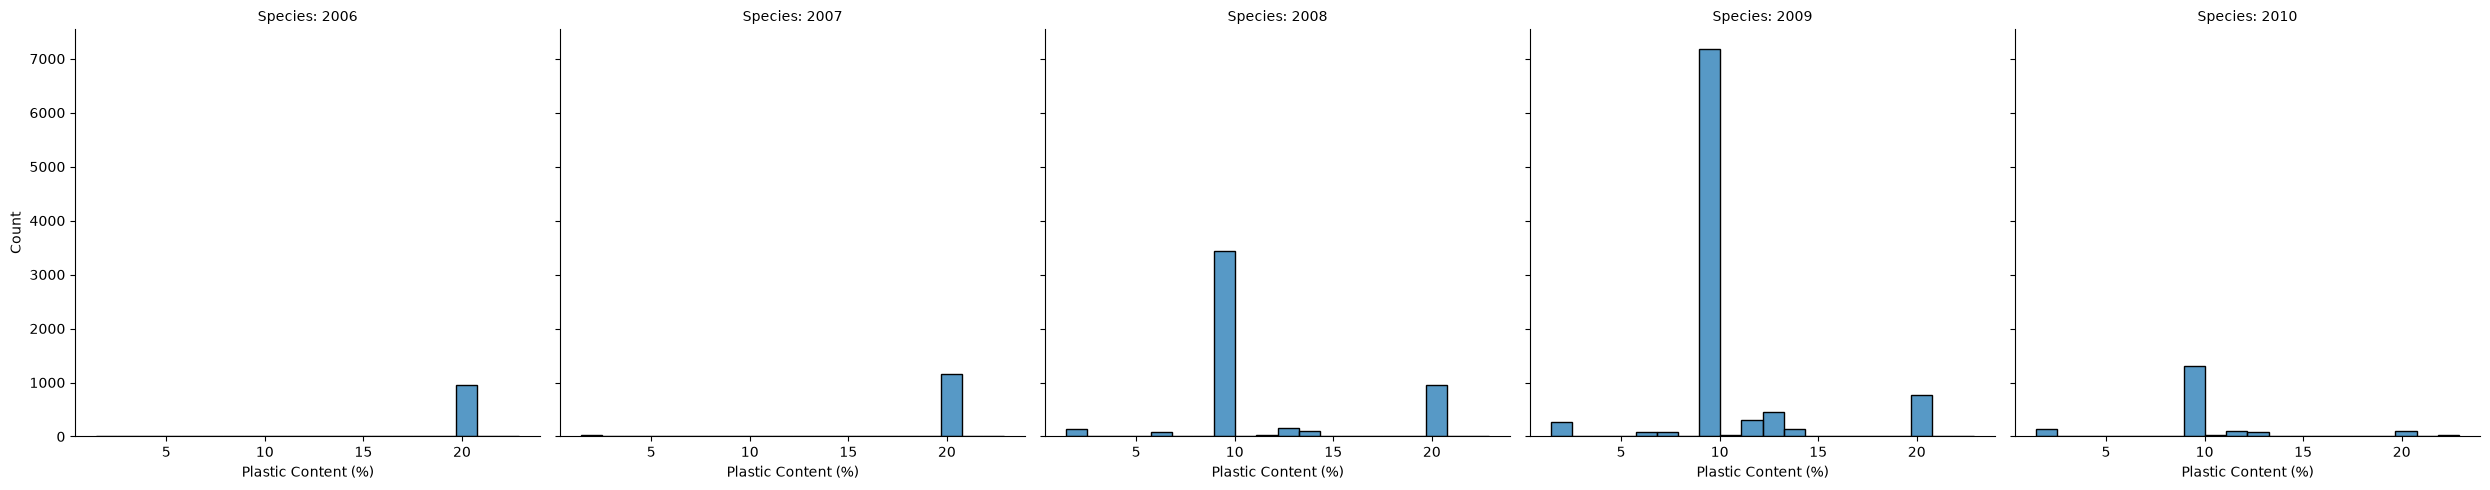

In [29]:
filtered_water = water[water['phenomenonTimeReferenceYear'].isin([2006, 2007, 2008, 2009, 2010])] 

g = sns.displot(filtered_water, x='composition_plastic_percent', col='phenomenonTimeReferenceYear', bins=20)
g.set_titles("Species: {col_name}")
g.set_axis_labels("Plastic Content (%)", "Count")
plt.show()

I initially generated this facet plot by using a full range of years, but there were around 40 plots generated and only the 5 years in this range seemed to have a significant amount of readings (especially 2009), so I selected those 5 to specifically examine. Something interesting to note is how, from 2008-2019, the three distributions share essentially the same unimodal distribution with a slight right skew centered around 10 percent of plastic content. However, in the prior years, our observations fall only under 20% plastic content, an extreme value that is listed as an outlier in our total distribution. It appears that the water quality data wasn't collected uniformly with respect to time, location, and water cleanliness, as it seems that year isn't exactly a good indicator to observe the difference in plastic concentration distribution.

Facet plots are a strong tool that add an extra layer of depth to the basic histogram, allowing us to observe the development and change of a distribution across a categorical variable. In this scenario, if the water quality samples were taken from random locations each year, it would likely greater resemble the total distribution.

Overall, this assignment was a great exercise to observe the best uses and applications of different charts to dive deeper into certain aspects of a dataset. If I were to redo this exercise, I'd likely choose a different dataset with more meaningful categorical variables and one that was more uniform throughout. Also, I'd explore further into using the violin plot, which I believe is the most powerful chart that I worked with in this assignment.